In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from scipy.stats import pearsonr

sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RUNS         = 5
NUM_EPOCHS     = 200
VALIDATE_EVERY = 50
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 20
HOLDOUT_FRAC   = 0.20
HOLDOUT_SEED   = 42
RESULTS_DIR    = 'results/benchmarking_combinatorial'

# sherlock / sherlock_synergy use parameters from norman_run.ipynb
_SLK = {'ce_lambda': 1e-1, 'l0_lambda': 5.,
        'combinatorial': True}

# (model_key, display_name, extra_kwargs, num_epochs)
METHODS = [
    ('vae',           'sherlock',         {**_SLK},                                     500),
    ('vae',           'sherlock_synergy', {**_SLK, 'use_synergy': True},                 500),
    ('cvae',          'cVAE',             {'combinatorial': True},                       NUM_EPOCHS),
    ('svae',          'sVAE',             {'sparse_mask_penalty': 10.0,
                                           'combinatorial': True},                       NUM_EPOCHS),
    ('contrastivevi', 'contrastiveVI',    {'combinatorial': True},                       NUM_EPOCHS),
    ('scgen',         'scgen',            {},                                             NUM_EPOCHS),
]

METRIC_COLS = [
    'ate_all_r',
    'ate_single_r',
    'ate_train_combo_r',
    'ate_held_r',
    'rho_z_pearson_r',
]

os.makedirs(f'{RESULTS_DIR}/models',  exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/figures', exist_ok=True)
print(f'Device: {DEVICE}  Results: {RESULTS_DIR}')

Device: cuda  Results: results/benchmarking_combinatorial


## Data loading and gene filtering

In [4]:
data = sc.read_h5ad('../../datasets/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]

# Gene filtering: top 2000 HVG union with perturbation target genes
pert_genes = set(g.strip() for p in all_perts if p != NTC for g in str(p).split('+'))
sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)
keep_mask = data.var['highly_variable'] | data.var_names.isin(pert_genes)
data = data[:, keep_mask].copy()

print(f'Cells: {data.n_obs}   Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}')

Cells: 111255   Genes: 2040
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Ground-truth treatment effects

Computed on the **full** dataset (including held-out combos) so we have a ground-truth ATE reference for all perturbations.

In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f'treat_effect: {treat_effect_adata.n_obs} perturbations × {treat_effect_adata.n_vars} genes')

100%|██████████| 236/236 [00:03<00:00, 65.88it/s]

treat_effect: 236 perturbations × 2040 genes


## Hold-out split (20% of combo perturbations)

A fixed random 20% of combo perts are withheld from **all** models' training data.  
`ate_held_r` on these tests each model's out-of-distribution combinatorial prediction.

In [6]:
rng           = np.random.default_rng(HOLDOUT_SEED)
combo_arr     = np.array(sorted(combo_perts))
n_holdout     = max(1, int(np.round(len(combo_arr) * HOLDOUT_FRAC)))
holdout_combos = set(combo_arr[rng.choice(len(combo_arr), size=n_holdout, replace=False)])
train_combos   = set(combo_arr) - holdout_combos

train_data = data[~data.obs[p_key].isin(holdout_combos)].copy()

print(f'Total combo perts : {len(combo_perts)}')
print(f'Training combos   : {len(train_combos)}')
print(f'Hold-out combos   : {len(holdout_combos)}  ({len(holdout_combos)/len(combo_perts):.1%})')
print(f'Training cells    : {train_data.n_obs} / {data.n_obs}')

Total combo perts : 131
Training combos   : 105
Hold-out combos   : 26  (19.8%)
Training cells    : 103000 / 111255


## Evaluation helper

In [7]:
def _ate_r(pred_df, obs_df, idx):
    idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
    if len(idx) < 2:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return float(pearsonr(x[v], y[v])[0]) if v.sum() > 2 else float('nan')


def evaluate_combinatorial(
    model, train_adata, full_adata, treat_effect_adata,
    single_perts, train_combos, holdout_combos, device
):
    """Compute ATE breakdown and rho-z consistency. No cluster ground-truth required."""
    # Inference on training data → rho_corr / z_corr
    slk.tl.eval(model, train_adata, obsm_key='z', uns_key='_bench_tmp', device=device)
    res = train_adata.uns['_bench_tmp']

    rho_z_r = float('nan')
    rho_mat = res.get('rho_corr')
    z_mat   = res.get('z_corr')
    if rho_mat is not None and z_mat is not None:
        rho = np.asarray(rho_mat, dtype=float)
        z   = np.asarray(z_mat,   dtype=float)
        if rho.shape == z.shape and rho.shape[0] >= 2:
            triu = np.triu_indices(rho.shape[0], k=1)
            rf, zf = rho[triu], z[triu]
            v = np.isfinite(rf) & np.isfinite(zf)
            if v.sum() > 2:
                rho_z_r = float(abs(pearsonr(rf[v], zf[v])[0]))

    # ATE: predict for all perts including held-out combos
    try:
        ate = model.predict_counterfactual_effects(
            full_adata, n_centroids=25, observed_effect=treat_effect_adata
        )
    except Exception as e:
        print(f'  Warning: ATE on full data failed ({e}), using train_adata')
        ate = model.predict_counterfactual_effects(
            train_adata, n_centroids=25, observed_effect=treat_effect_adata
        )

    pred = ate['predicted_df']
    obs  = ate['observed_df']

    return {
        'ate_all_r':         ate['corr'],
        'ate_single_r':      _ate_r(pred, obs, single_perts),
        'ate_train_combo_r': _ate_r(pred, obs, list(train_combos)),
        'ate_held_r':        _ate_r(pred, obs, list(holdout_combos)),
        'rho_z_pearson_r':   rho_z_r,
    }

## Benchmark loop

Each method is trained `N_RUNS` times on the training subset (all singles + NTC + 80% combos).  
The best-scoring run per method (by mean of `METRIC_COLS`) is saved to disk.

**Note:** `ate_held_r` will be NaN for non-combinatorial methods (e.g. scgen) that cannot predict unseen combo labels.

In [8]:
records        = []
best_run_out   = {}
best_run_score = {}

for model_key, display_name, extra_kwargs, method_epochs in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs, {method_epochs} epochs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    for run in range(N_RUNS):
        print(f'  -- {display_name} run {run+1}/{N_RUNS} --')

        out = slk.tl.run(
            train_data,
            model=model_key,
            batch_size=BATCH_SIZE,
            num_epochs=method_epochs,
            device=DEVICE,
            latent_dim=LATENT_DIM,
            patience=PATIENCE,
            validate_every=VALIDATE_EVERY,
            seed=run,
            **extra_kwargs,
        )
        model = out['model']

        metrics = evaluate_combinatorial(
            model, train_data, data, treat_effect_adata,
            single_perts, train_combos, holdout_combos, DEVICE,
        )

        run_avg = float(metrics['ate_all_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                print(f'    {k:25s} = {v:.4f}' if np.isfinite(float(v)) else f'    {k:25s} = NaN')

    save_path = f'{RESULTS_DIR}/models/{display_name}_best.pth'
    slk.tl.save_results(best_run_out[display_name], save_path)
    print(f'  Saved best {display_name} → {save_path}')

results_df = pd.DataFrame(records)
print('\nDone.')


sherlock  (5 runs, 500 epochs)
  -- sherlock run 1/5 --
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [24:25<00:00,  2.93s/it, ATE=0.6296, CE=4.6903, ELBO=1341.0587, KLw=1.00, R2_ntc=0.9133, R2_p=0.9298, acc=0.317, pi25=0.02, pi99=1.00, tau=0.300]  


    ate_all_r                 = 0.6237
    ate_single_r              = 0.5531
    ate_train_combo_r         = 0.6626
    ate_held_r                = 0.6360
    rho_z_pearson_r           = 0.7064
  -- sherlock run 2/5 --
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [20:53<00:00,  2.51s/it, ATE=0.6543, CE=4.6536, ELBO=1340.8160, KLw=1.00, R2_ntc=0.9273, R2_p=0.9308, acc=0.321, pi25=0.02, pi99=1.00, tau=0.300] 


    ate_all_r                 = 0.6468
    ate_single_r              = 0.6029
    ate_train_combo_r         = 0.6788
    ate_held_r                = 0.6468
    rho_z_pearson_r           = 0.7360
  -- sherlock run 3/5 --
Training VAE on cuda …


...

    ate_all_r                 = 0.4542
    ate_single_r              = 0.3905
    ate_train_combo_r         = 0.4867
    ate_held_r                = 0.5024
    rho_z_pearson_r           = 1.0000
  -- scgen run 4/5 --


scGEN: 100%|██████████| 200/200 [07:56<00:00,  2.38s/it, ATE=0.8492, R2=0.8494, loss=89.9735]


    ate_all_r                 = 0.4616
    ate_single_r              = 0.3938
    ate_train_combo_r         = 0.4934
    ate_held_r                = 0.5184
    rho_z_pearson_r           = 1.0000
  -- scgen run 5/5 --


scGEN: 100%|██████████| 200/200 [07:58<00:00,  2.39s/it, ATE=0.8242, R2=0.8498, loss=89.9697]


    ate_all_r                 = 0.4715
    ate_single_r              = 0.4030
    ate_train_combo_r         = 0.5063
    ate_held_r                = 0.5202
    rho_z_pearson_r           = 1.0000
  Saved best scgen → results/benchmarking_combinatorial/models/scgen_best.pth

Done.


## Results summary

In [9]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
# Preserve METHODS order
method_order = [m[1] for m in METHODS]
summary = summary.reindex([m for m in method_order if m in summary.index])
print(summary.to_string())

                 ate_all_r         ate_single_r         ate_train_combo_r         ate_held_r         rho_z_pearson_r        
                      mean     std         mean     std              mean     std       mean     std            mean     std
method                                                                                                                      
sherlock            0.6391  0.0179       0.5834  0.0286            0.6728  0.0175     0.6426  0.0111          0.7429  0.0288
sherlock_synergy    0.5729  0.1149       0.5231  0.1171            0.5950  0.1231     0.5910  0.0963          0.7899  0.0369
cVAE                0.4718  0.0065       0.4700  0.0085            0.4857  0.0078     0.4406  0.0078          0.9472  0.0137
sVAE                0.4376  0.0061       0.4302  0.0055            0.4552  0.0081     0.3997  0.0065          0.9396  0.0115
contrastiveVI       0.3839  0.0191       0.3571  0.0235            0.3926  0.0199     0.3898  0.0142          1.0000  0.0000


## Plots

/var/tmp/ipykernel_2572735/3511407431.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  single_sample = df_melted.groupby(['metric', 'method'])['value'].size().max() == 1


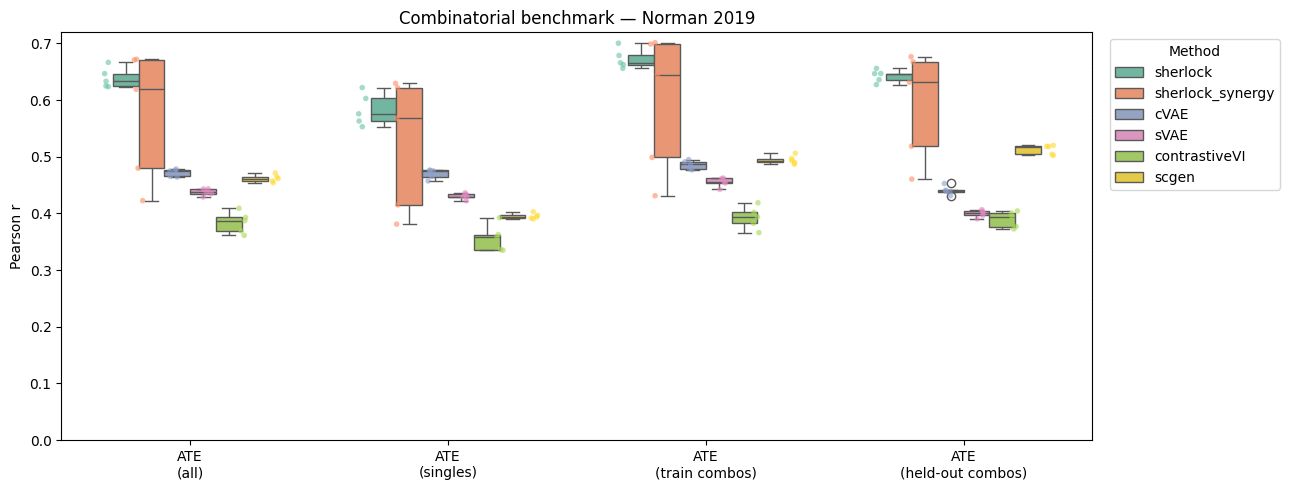

In [10]:
label_map = {
    'ate_all_r':         'ATE\n(all)',
    'ate_single_r':      'ATE\n(singles)',
    'ate_train_combo_r': 'ATE\n(train combos)',
    'ate_held_r':        'ATE\n(held-out combos)',
    'rho_z_pearson_r':   'ρ-z\nCorr r',
}

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS[:-1], var_name='metric', value_name='value'
)
df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS[:-1]],
    ordered=True,
)
df_melted['method'] = pd.Categorical(
    df_melted['method'], categories=method_order, ordered=True
)
df_melted['value'] = df_melted['value'].clip(lower=0)

single_sample = df_melted.groupby(['metric', 'method'])['value'].size().max() == 1

fig, ax = plt.subplots(figsize=(13, 5))

if single_sample:
    sns.barplot(
        data=df_melted, x='metric_label', y='value', hue='method',
        palette='Set2', ax=ax, errorbar=None,
    )
else:
    sns.boxplot(
        data=df_melted, x='metric_label', y='value', hue='method',
        palette='Set2', width=0.6, ax=ax,
    )
    sns.stripplot(
        data=df_melted, x='metric_label', y='value', hue='method',
        palette='Set2', dodge=True, size=4, alpha=0.6, legend=False, ax=ax,
    )

ax.set_xlabel('')
ax.set_ylabel('Pearson r')
ax.set_title('Combinatorial benchmark — Norman 2019')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
# Separator: ATE metrics | rho_z
ax.axvline(3.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()
plot_name = 'benchmark_barplot.pdf' if single_sample else 'benchmark_boxplot.pdf'
plt.savefig(f'{RESULTS_DIR}/figures/{plot_name}', bbox_inches='tight')
plt.show()